# SDF File Reading and UQ Analysis with Covariance

This notebook demonstrates:
1. Reading SDF sensitivity files
2. Exploring SDFData structure and attributes
3. Visualizing sensitivity profiles
4. Loading covariance matrices
5. Performing uncertainty quantification using the sandwich rule
6. Analyzing uncertainty contributions

## 1. Imports and Setup

In [1]:
# Reload modules to pick up any fixes
import importlib
import sys
if 'kika' in sys.modules:
    importlib.reload(sys.modules['kika.sensitivities.sdf_parser'])

import kika
from kika.UQ.sandwich import sandwich_uncertainty_propagation
from kika.plotting.covariance import plot_covariance_heatmap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Set up paths
base_path = Path(r"C:\Users\Usuario\BaradDur\Dev\kika")
sdf_path = base_path / "files" / "sdf" / "SERPENT_Sensitivity_Analysis_sens_ratio_BIN_1.sdf"
cov_path = base_path / "files" / "cov" / "scale.rev05.44groupcov.txt"

print(f"SDF file exists: {sdf_path.exists()}")
print(f"Covariance file exists: {cov_path.exists()}")

SDF file exists: True
Covariance file exists: True


## 2. Load SDF File

In [2]:
# Read the SDF file
sdf_data = kika.read_sdf(str(sdf_path))

# Display basic metadata
print(f"Title: {sdf_data.title}")
print(f"Energy label: {sdf_data.energy}")
print(f"Number of energy groups: {len(sdf_data.pert_energies) - 1}")
print(f"Number of sensitivity profiles: {len(sdf_data.data)}")
print(f"Reference response value: {sdf_data.r0:.6e}")
print(f"Response relative error: {sdf_data.e0:.6e}")
print(f"Energy range: {sdf_data.pert_energies[0]:.2e} - {sdf_data.pert_energies[-1]:.2e} MeV")

Title: SERPENT Sensitivity Analysis
Energy label: 1.00E-11_2.00E+01
Number of energy groups: 44
Number of sensitivity profiles: 14
Reference response value: 6.184000e-04
Response relative error: 9.548096e-06
Energy range: 1.00e-11 - 2.00e+01 MeV


## 3. Explore SDFData Structure

The `SDFData` object contains:
- **data**: List of `SDFReactionData` objects, one per nuclide-reaction combination
- Each `SDFReactionData` has:
  - `zaid`: Nuclide identifier (e.g., 1001 for H-1)
  - `mt`: Reaction MT number
  - `nuclide`: Auto-calculated nuclide symbol
  - `reaction_name`: Auto-calculated reaction name
  - `sensitivity`: Sensitivity coefficients per energy group
  - `error`: Relative errors per energy group

In [3]:
# Create a summary table of all reactions in the SDF file
reactions_summary = []
for sens in sdf_data.data:
    reactions_summary.append({
        'Nuclide': sens.nuclide,
        'ZAID': sens.zaid,
        'MT': sens.mt,
        'Reaction': sens.reaction_name,
        'Max Sensitivity': f"{np.max(np.abs(sens.sensitivity)):.4e}",
        'Non-zero Groups': np.count_nonzero(sens.sensitivity)
    })

df_summary = pd.DataFrame(reactions_summary)
print(f"\nAll reactions in SDF file ({len(df_summary)} total):\n")
print(df_summary.to_string(index=False))


All reactions in SDF file (14 total):

Nuclide  ZAID  MT   Reaction Max Sensitivity  Non-zero Groups
    H-1  1001   1 (n,total).      6.7909e-01                7
    H-1  1001   2     (z,z0)      6.7906e-01                7
    H-1  1001 102     (z,Î³)      2.9240e-05                2
   O-16  8016   1 (n,total).      1.8055e-01                7
   O-16  8016   2     (z,z0)      1.8055e-01                7
  Fe-54 26054   1 (n,total).      4.7847e-02                7
  Fe-54 26054   2     (z,z0)      4.7199e-02                7
  Fe-54 26054   4     (z,n')      1.4867e-02                4
  Fe-54 26054 102     (z,Î³)      6.4833e-04                5
  Fe-54 26054 103      (z,p)      2.4370e-03                4
  Fe-56 26056   1 (n,total).      5.4231e-01                7
  Fe-56 26056   2     (z,z0)      2.5229e-01                7
  Fe-56 26056   4     (z,n')      2.8928e-01                6
  Fe-56 26056 102     (z,Î³)      6.5603e-03                7


In [4]:
# Examine a specific reaction in detail
print("\n" + "="*60)
print("Example: H-1 (n,total) sensitivity details")
print("="*60)

h1_total = [s for s in sdf_data.data if s.zaid == 1001 and s.mt == 1][0]
print(f"Nuclide: {h1_total.nuclide}")
print(f"Reaction: {h1_total.reaction_name} (MT={h1_total.mt})")
print(f"\nSensitivity coefficients (first 10 groups):")
for i in range(min(10, len(h1_total.sensitivity))):
    print(f"  Group {i+1}: {h1_total.sensitivity[i]:12.6e} ± {h1_total.error[i]:12.6e}")
print(f"  ...")
print(f"\nTotal sensitivity: {np.sum(h1_total.sensitivity):.6e}")


Example: H-1 (n,total) sensitivity details
Nuclide: H-1
Reaction: (n,total). (MT=1)

Sensitivity coefficients (first 10 groups):
  Group 1: 0.000000e+00 ± 0.000000e+00
  Group 2: 0.000000e+00 ± 0.000000e+00
  Group 3: 0.000000e+00 ± 0.000000e+00
  Group 4: 0.000000e+00 ± 0.000000e+00
  Group 5: 0.000000e+00 ± 0.000000e+00
  Group 6: 0.000000e+00 ± 0.000000e+00
  Group 7: 0.000000e+00 ± 0.000000e+00
  Group 8: 0.000000e+00 ± 0.000000e+00
  Group 9: 0.000000e+00 ± 0.000000e+00
  Group 10: 0.000000e+00 ± 0.000000e+00
  ...

Total sensitivity: -3.006193e+00


## 4. Visualize Sensitivity Profiles

Plot energy-dependent sensitivity coefficients for key nuclides and reactions.

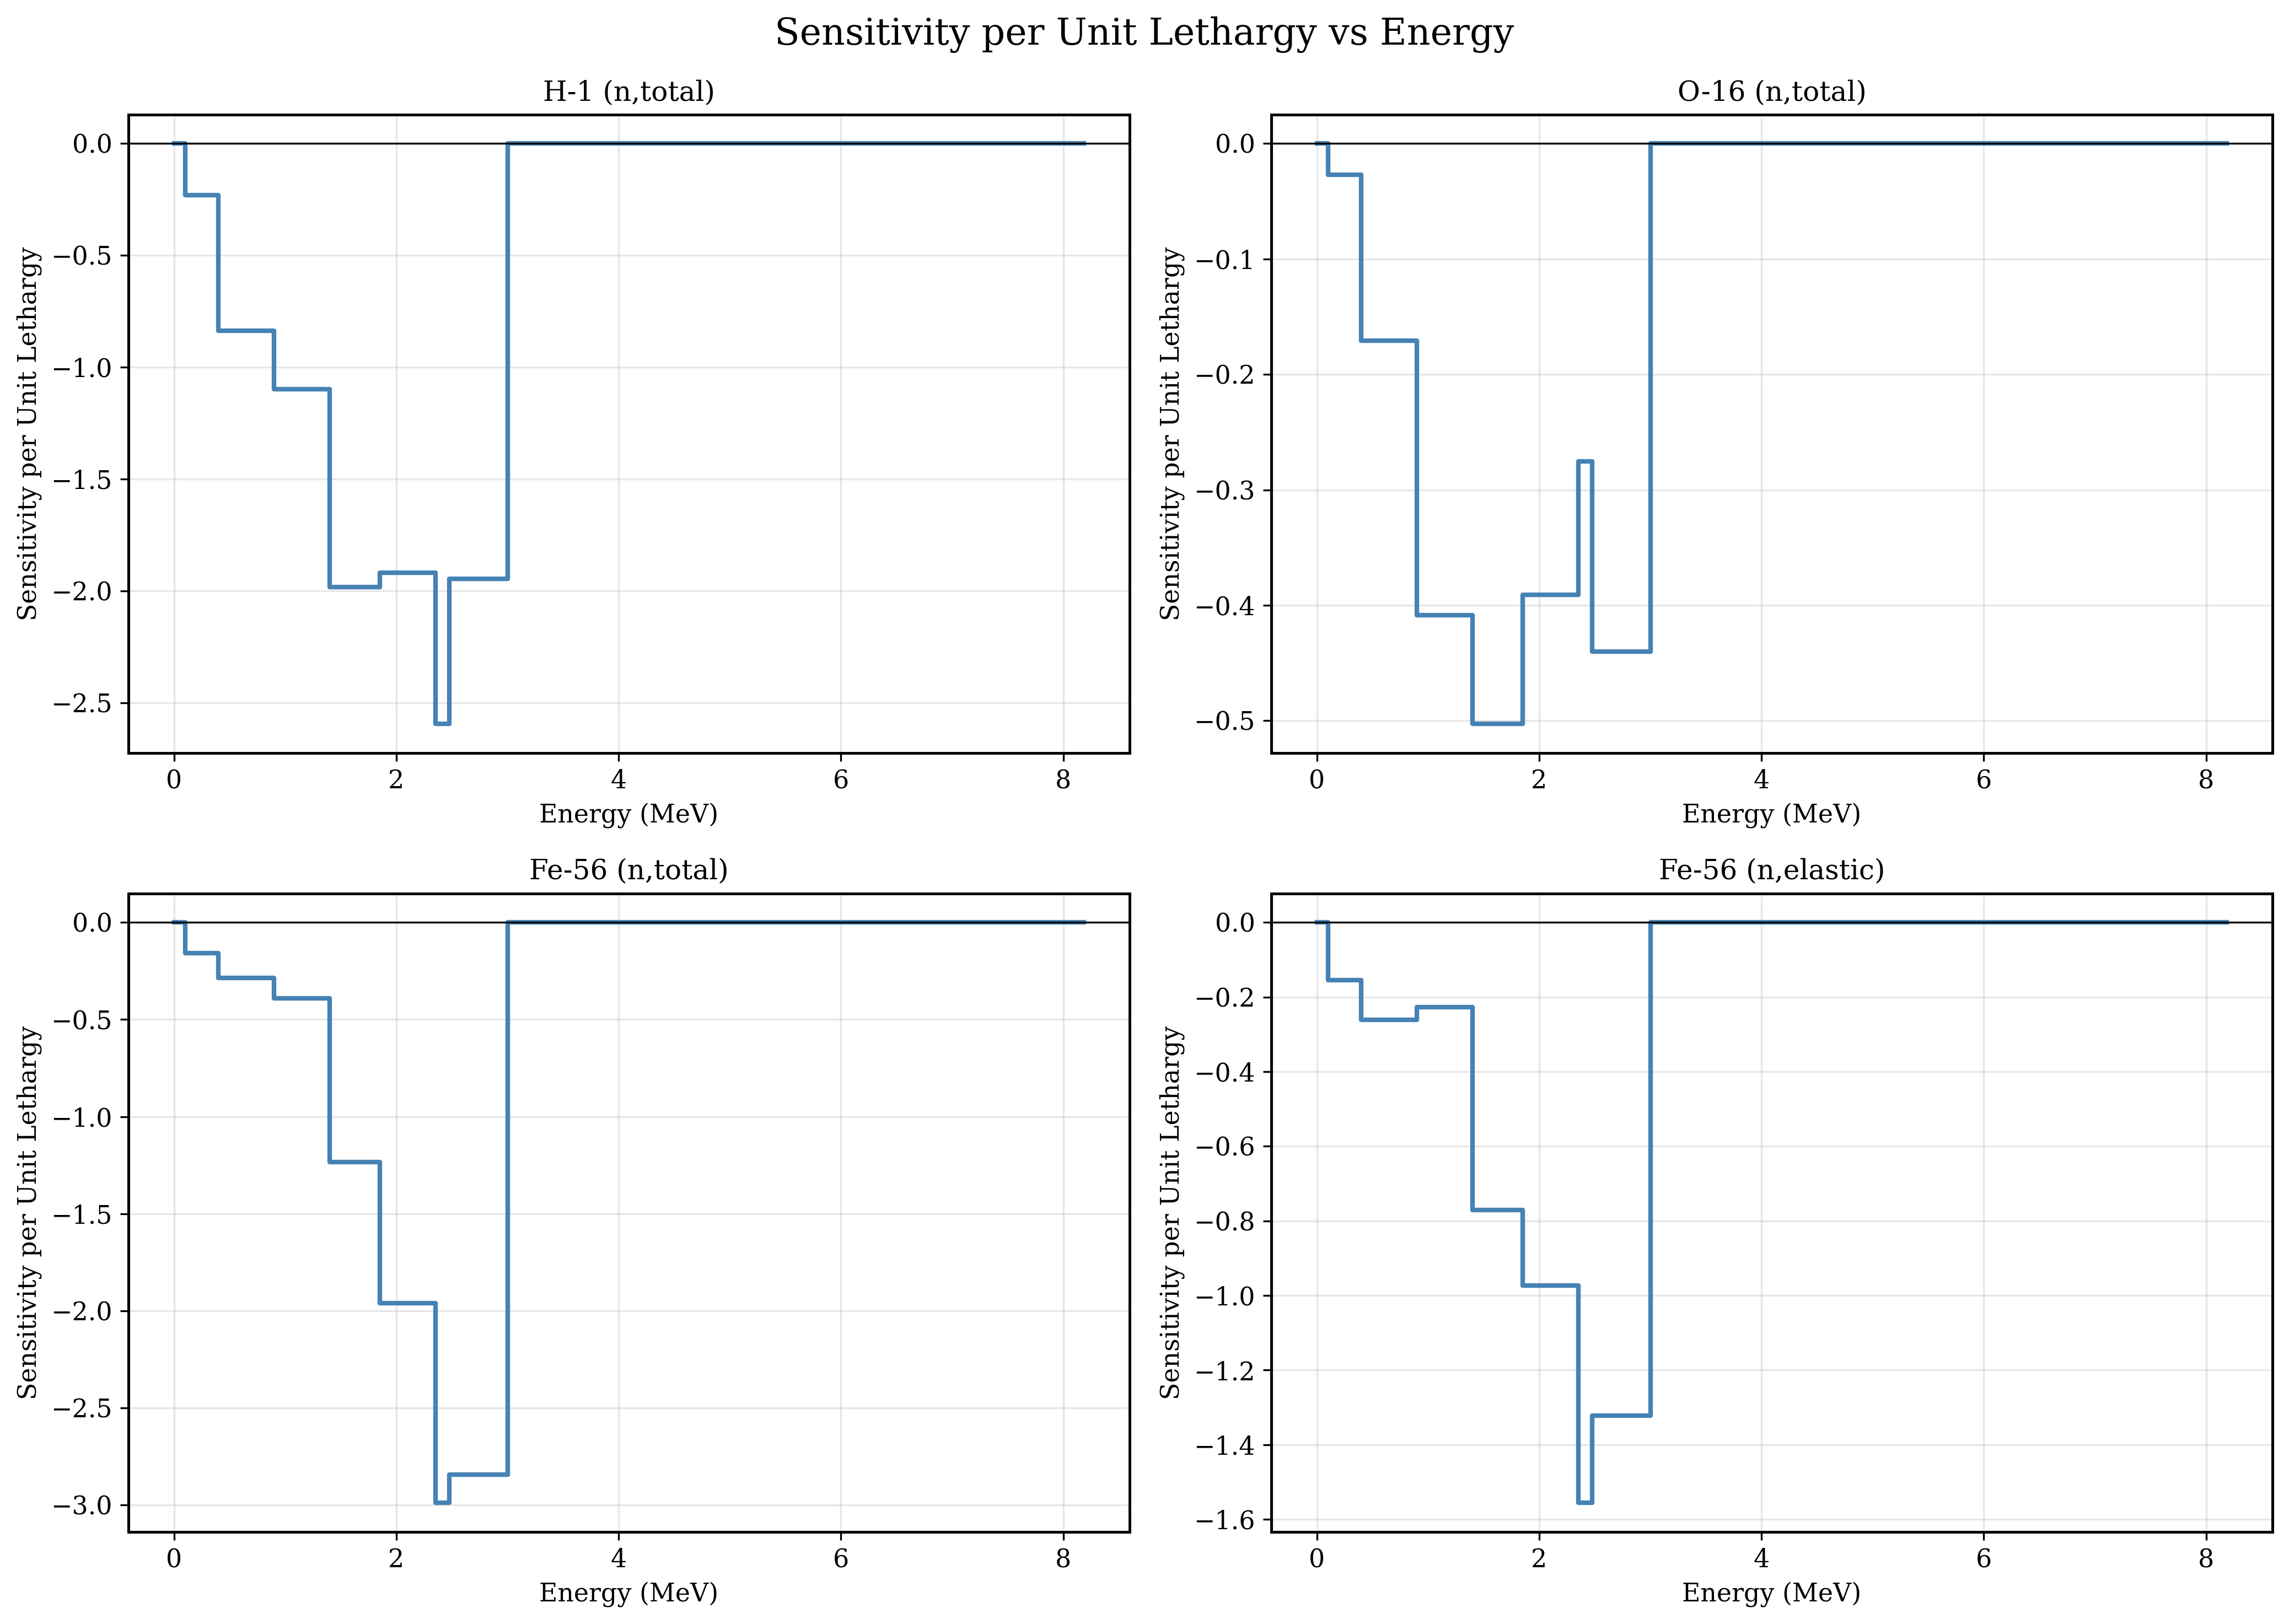

In [24]:
# Plot sensitivity per lethargy vs energy
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sensitivity per Unit Lethargy vs Energy', fontsize=16)

# Select key reactions to plot
reactions_to_plot = [
    (1001, 1, 'H-1 (n,total)'),
    (8016, 1, 'O-16 (n,total)'),
    (26056, 1, 'Fe-56 (n,total)'),
    (26056, 2, 'Fe-56 (n,elastic)')
]

# Get energy bounds
energy_bounds = np.array(sdf_data.pert_energies)

for idx, (zaid, mt, label) in enumerate(reactions_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    # Find the reaction in the SDF data
    reaction_data = [s for s in sdf_data.data if s.zaid == zaid and s.mt == mt]
    
    if reaction_data:
        sens_data = reaction_data[0]
        
        # Calculate lethargy width for each energy bin
        # Lethargy u = ln(E_max/E), so Δu = ln(E_upper/E_lower)
        lethargy_width = np.log(energy_bounds[1:] / energy_bounds[:-1])
        
        # Calculate sensitivity per unit lethargy
        sens_per_lethargy = np.array(sens_data.sensitivity) / lethargy_width
        
        # Plot as step function
        ax.step(energy_bounds[:-1], sens_per_lethargy, where='post', linewidth=2, color='steelblue')
        ax.set_xlabel('Energy (MeV)', fontsize=11)
        ax.set_ylabel('Sensitivity per Unit Lethargy', fontsize=11)
        ax.set_title(label, fontsize=12)
        ax.set_xscale('linear')
        ax.grid(True, alpha=0.3, which='both')
        ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
    else:
        ax.text(0.5, 0.5, f'{label}\nNot found in SDF', 
                ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.show()


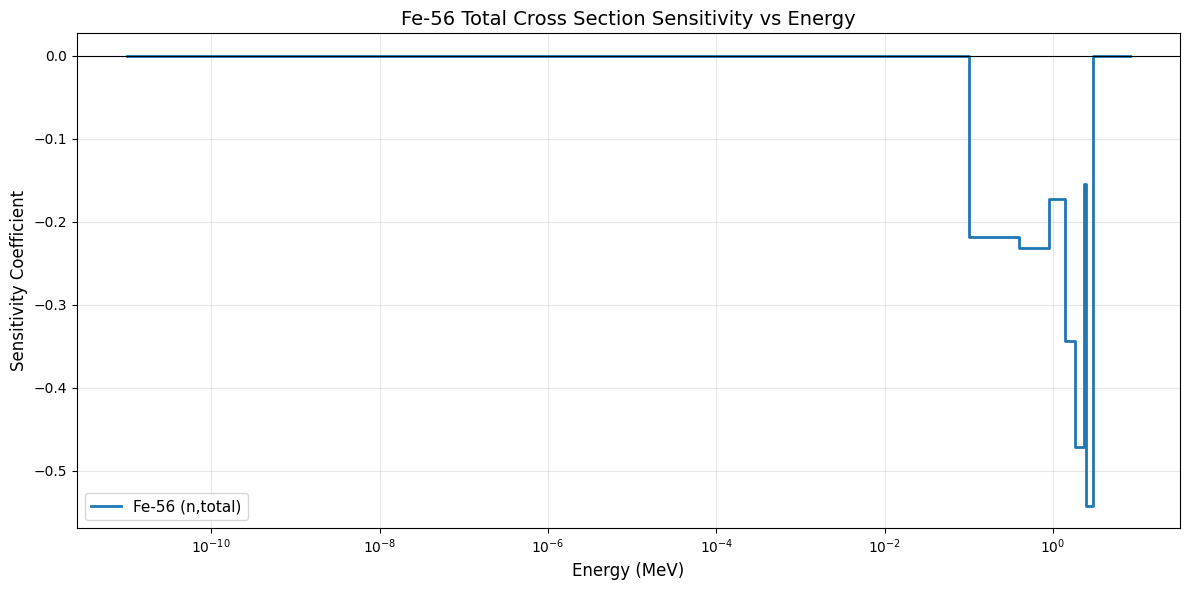

In [9]:
# Energy-dependent sensitivity plot (with energy scale)
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Fe-56 total sensitivity vs energy
fe56_total = [s for s in sdf_data.data if s.zaid == 26056 and s.mt == 1][0]
energy_bounds = np.array(sdf_data.pert_energies)

ax.step(energy_bounds[:-1], fe56_total.sensitivity, where='post', linewidth=2, label='Fe-56 (n,total)')
ax.set_xlabel('Energy (MeV)', fontsize=12)
ax.set_ylabel('Sensitivity Coefficient', fontsize=12)
ax.set_title('Fe-56 Total Cross Section Sensitivity vs Energy', fontsize=14)
ax.set_xscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.axhline(y=0, color='k', linestyle='-', linewidth=0.8)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Load Covariance Matrix

Load the SCALE 44-group covariance file and inspect its properties.

In [10]:
# Load the SCALE covariance file
covmat = kika.read_scale_covmat(str(cov_path))

print(f"Covariance matrix loaded successfully!")
print(f"\nCovariance matrix properties:")
print(f"  Number of energy groups: {covmat.num_groups}")
print(f"  Energy unit: {covmat.energy_unit}")
print(f"  Energy range: {covmat.energy_grid[0]:.2e} - {covmat.energy_grid[-1]:.2e} {covmat.energy_unit}")
print(f"  Number of isotopes: {len(covmat.isotopes)}")
print(f"  Number of stored covariance blocks: {covmat.num_matrices}")
print(f"\nIsotopes in covariance file (first 20):")
print(f"  {sorted(covmat.isotopes)[:20]}")
print(f"\nReactions in covariance file:")
print(f"  {sorted(covmat.reactions)}")
print(f"\nFull covariance matrix shape: {covmat.covariance_matrix.shape}")

Covariance matrix loaded successfully!

Covariance matrix properties:
  Number of energy groups: 44
  Energy unit: eV
  Energy range: 1.00e-11 - 2.00e+01 eV
  Number of isotopes: 407
  Number of stored covariance blocks: 2211

Isotopes in covariance file (first 20):
  [1001, 1002, 1003, 2003, 2004, 3006, 3007, 4007, 4009, 5010, 5011, 6000, 7014, 7015, 8016, 8017, 9019, 11023, 12000, 12024]

Reactions in covariance file:
  [2, 4, 16, 18, 22, 28, 102, 103, 104, 105, 106, 107]

Full covariance matrix shape: (77088, 77088)


In [13]:
# Display detailed breakdown of reactions per isotope
from kika._constants import ATOMIC_NUMBER_TO_SYMBOL

print("\nDetailed reaction breakdown by isotope (first 15):")
print("="*60)
for i, isotope in enumerate(sorted(covmat.isotopes)):
    if i >= 15:
        print(f"... and {len(covmat.isotopes) - 15} more isotopes")
        break
    reactions = covmat.reactions_by_isotope(isotope)
    # Convert ZAID to symbol
    z = isotope // 1000
    a = isotope % 1000
    symbol = f"{ATOMIC_NUMBER_TO_SYMBOL.get(z, f'Z{z}')}-{a}"
    print(f"{symbol:8s} (ZAID {isotope}): MT = {sorted(reactions)}")


Detailed reaction breakdown by isotope (first 15):
H-1      (ZAID 1001): MT = [2, 102]
H-2      (ZAID 1002): MT = [2, 16, 102]
H-3      (ZAID 1003): MT = [2, 16]
He-3     (ZAID 2003): MT = [2, 102, 103, 104]
He-4     (ZAID 2004): MT = [2]
Li-6     (ZAID 3006): MT = [2, 4, 102, 103, 105]
Li-7     (ZAID 3007): MT = [2, 4, 102, 104]
Be-7     (ZAID 4007): MT = [2]
Be-9     (ZAID 4009): MT = [2, 16, 102, 103, 104, 105, 107]
B-10     (ZAID 5010): MT = [2, 4, 102, 103, 104, 107]
B-11     (ZAID 5011): MT = [2, 4, 16, 102, 103, 105, 107]
C-0      (ZAID 6000): MT = [2, 4, 102, 103, 104, 107]
N-14     (ZAID 7014): MT = [2, 4, 16, 102, 103, 104, 105, 107]
N-15     (ZAID 7015): MT = [2, 4, 16, 102, 103, 104, 105, 107]
O-16     (ZAID 8016): MT = [2, 4, 16, 102, 103, 104, 105, 107]
... and 392 more isotopes


## 6. Visualize Covariance/Correlation Matrices

Plot correlation matrices for Fe-56 reactions to see energy-group correlations.

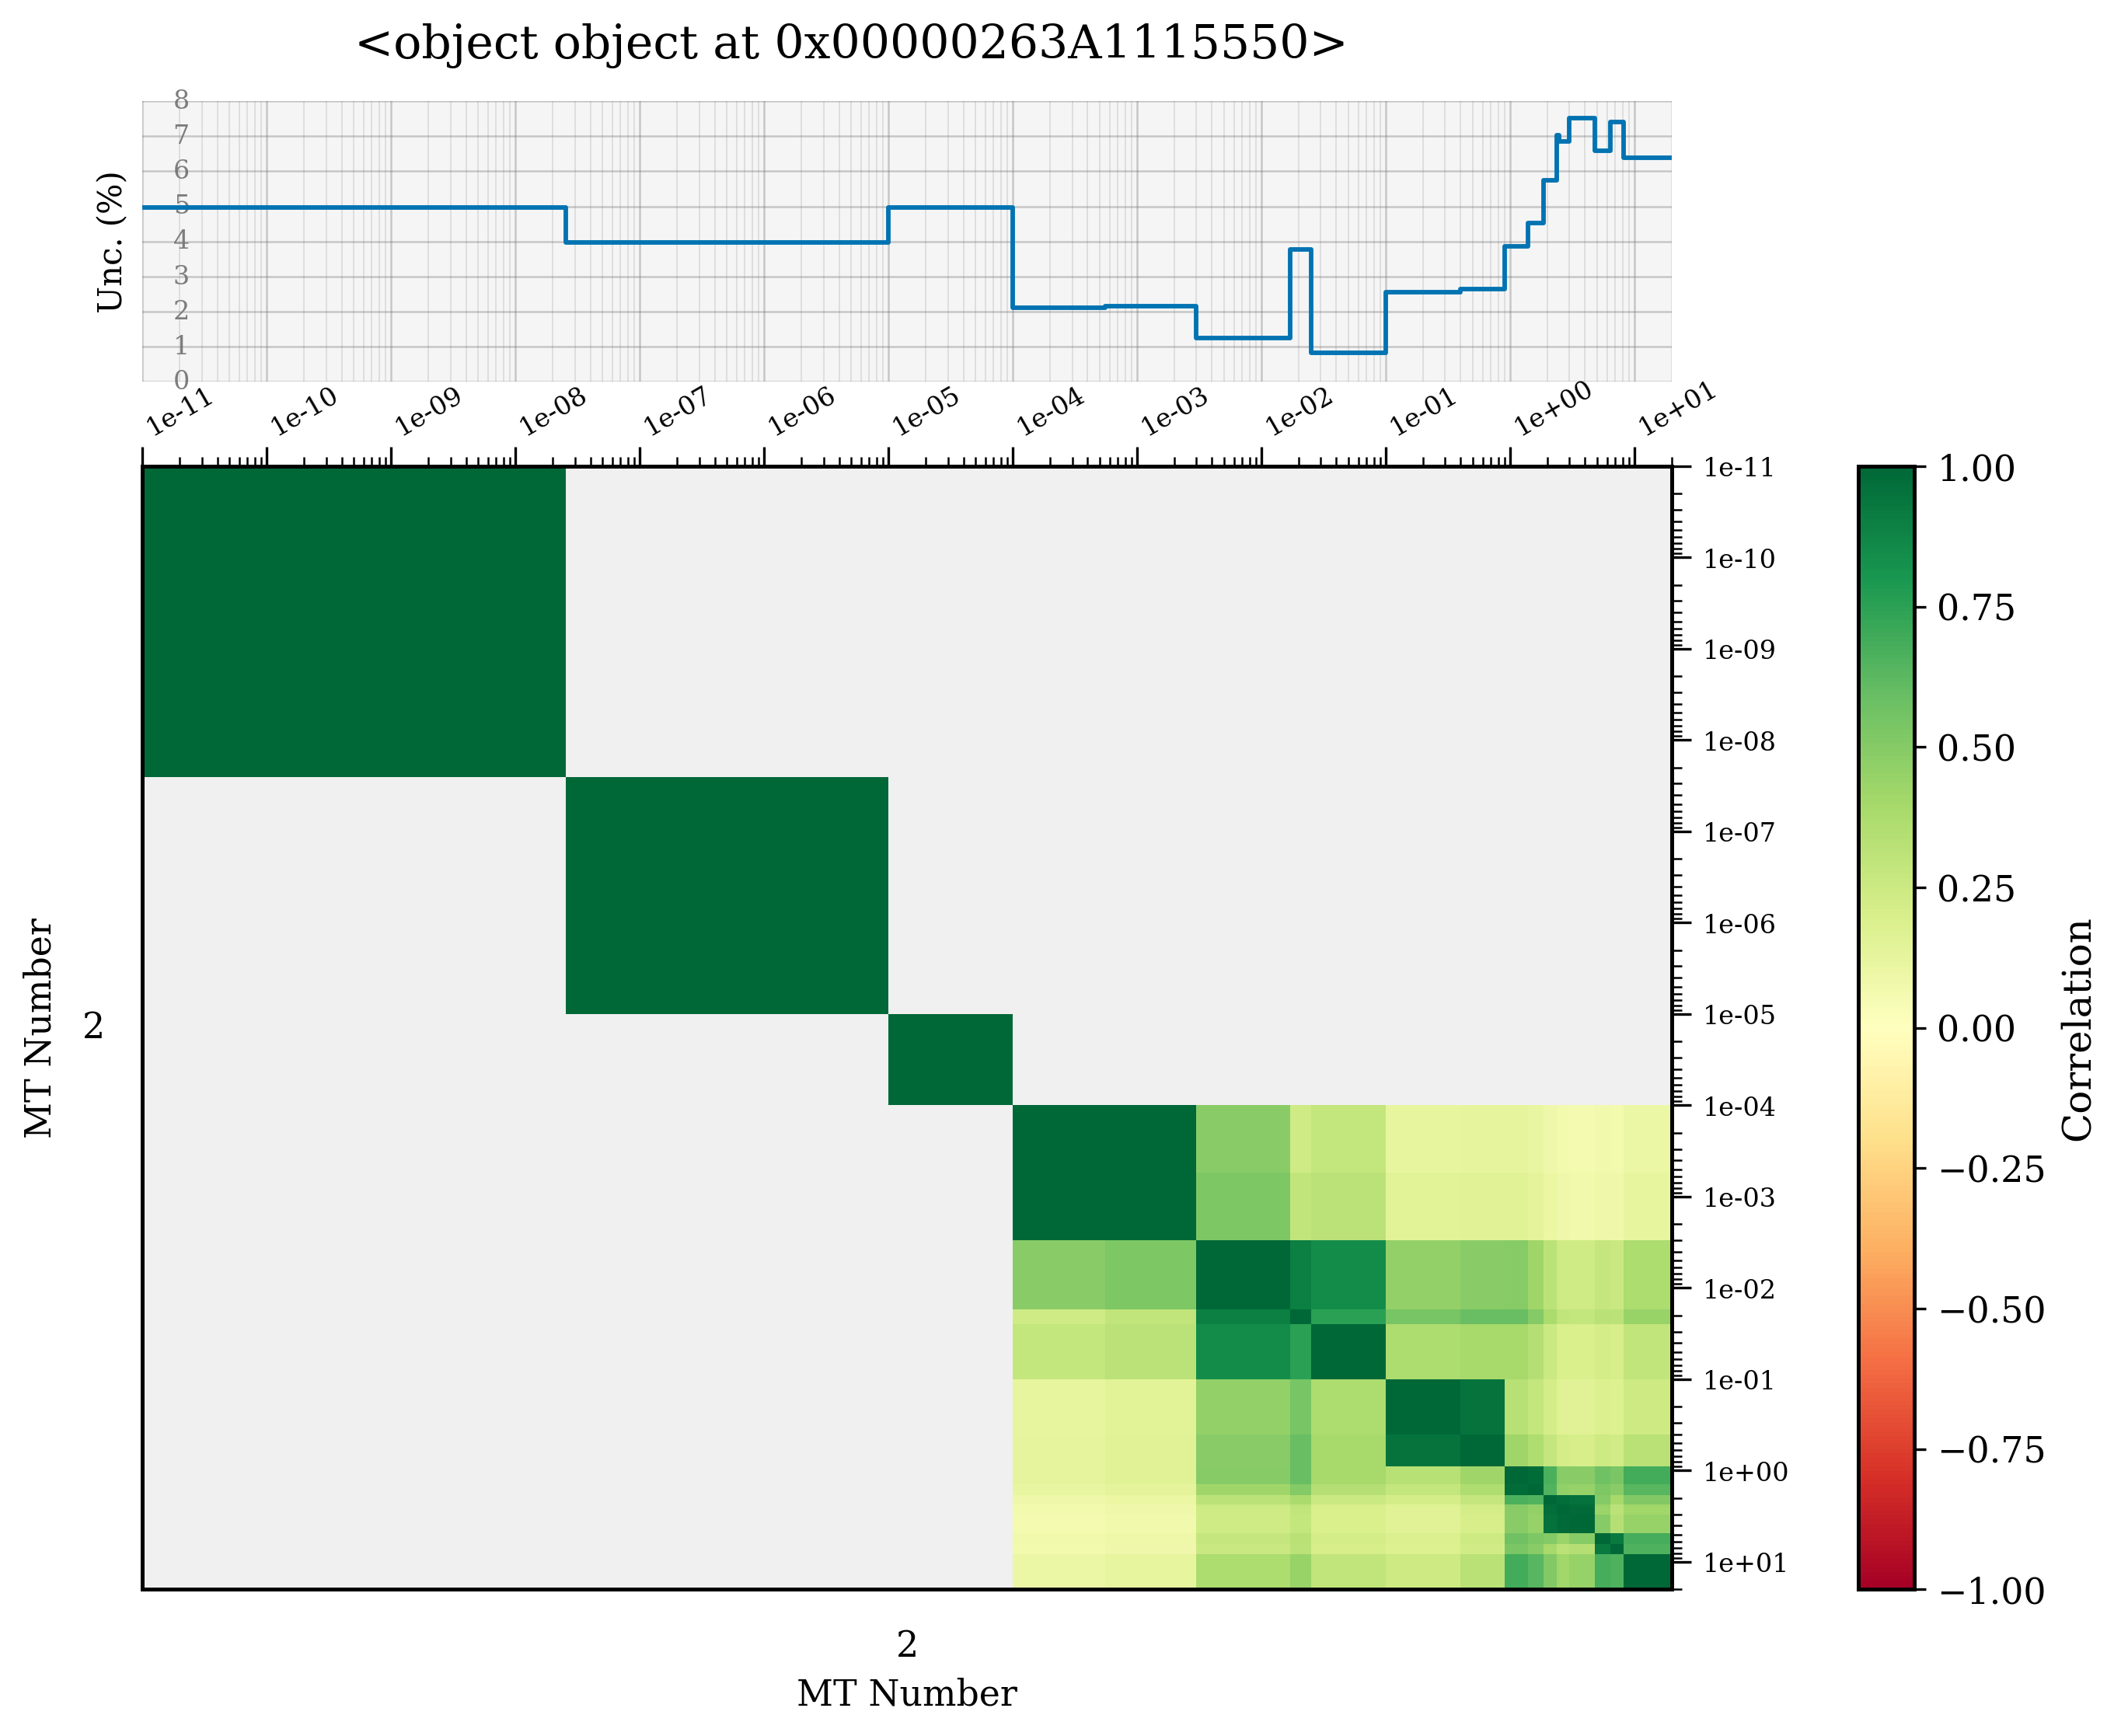

In [22]:
# Plot correlation matrix for Fe-56 elastic scattering
if 26056 in covmat.isotopes:
    try:
        fig = plot_covariance_heatmap(
            covmat,
            nuclide=26056,
            mt=2,  # Elastic scattering
            matrix_type="corr",  # Correlation matrix
            figsize=(8, 7),
            show_uncertainties=True,
            scale="log"
        )
        plt.show()
    except Exception as e:
        print(f"Could not plot Fe-56 elastic correlation: {e}")
        print("Available reactions for Fe-56:", covmat.get_reactions_for_isotope(26056))
else:
    print("Fe-56 not found in covariance file")

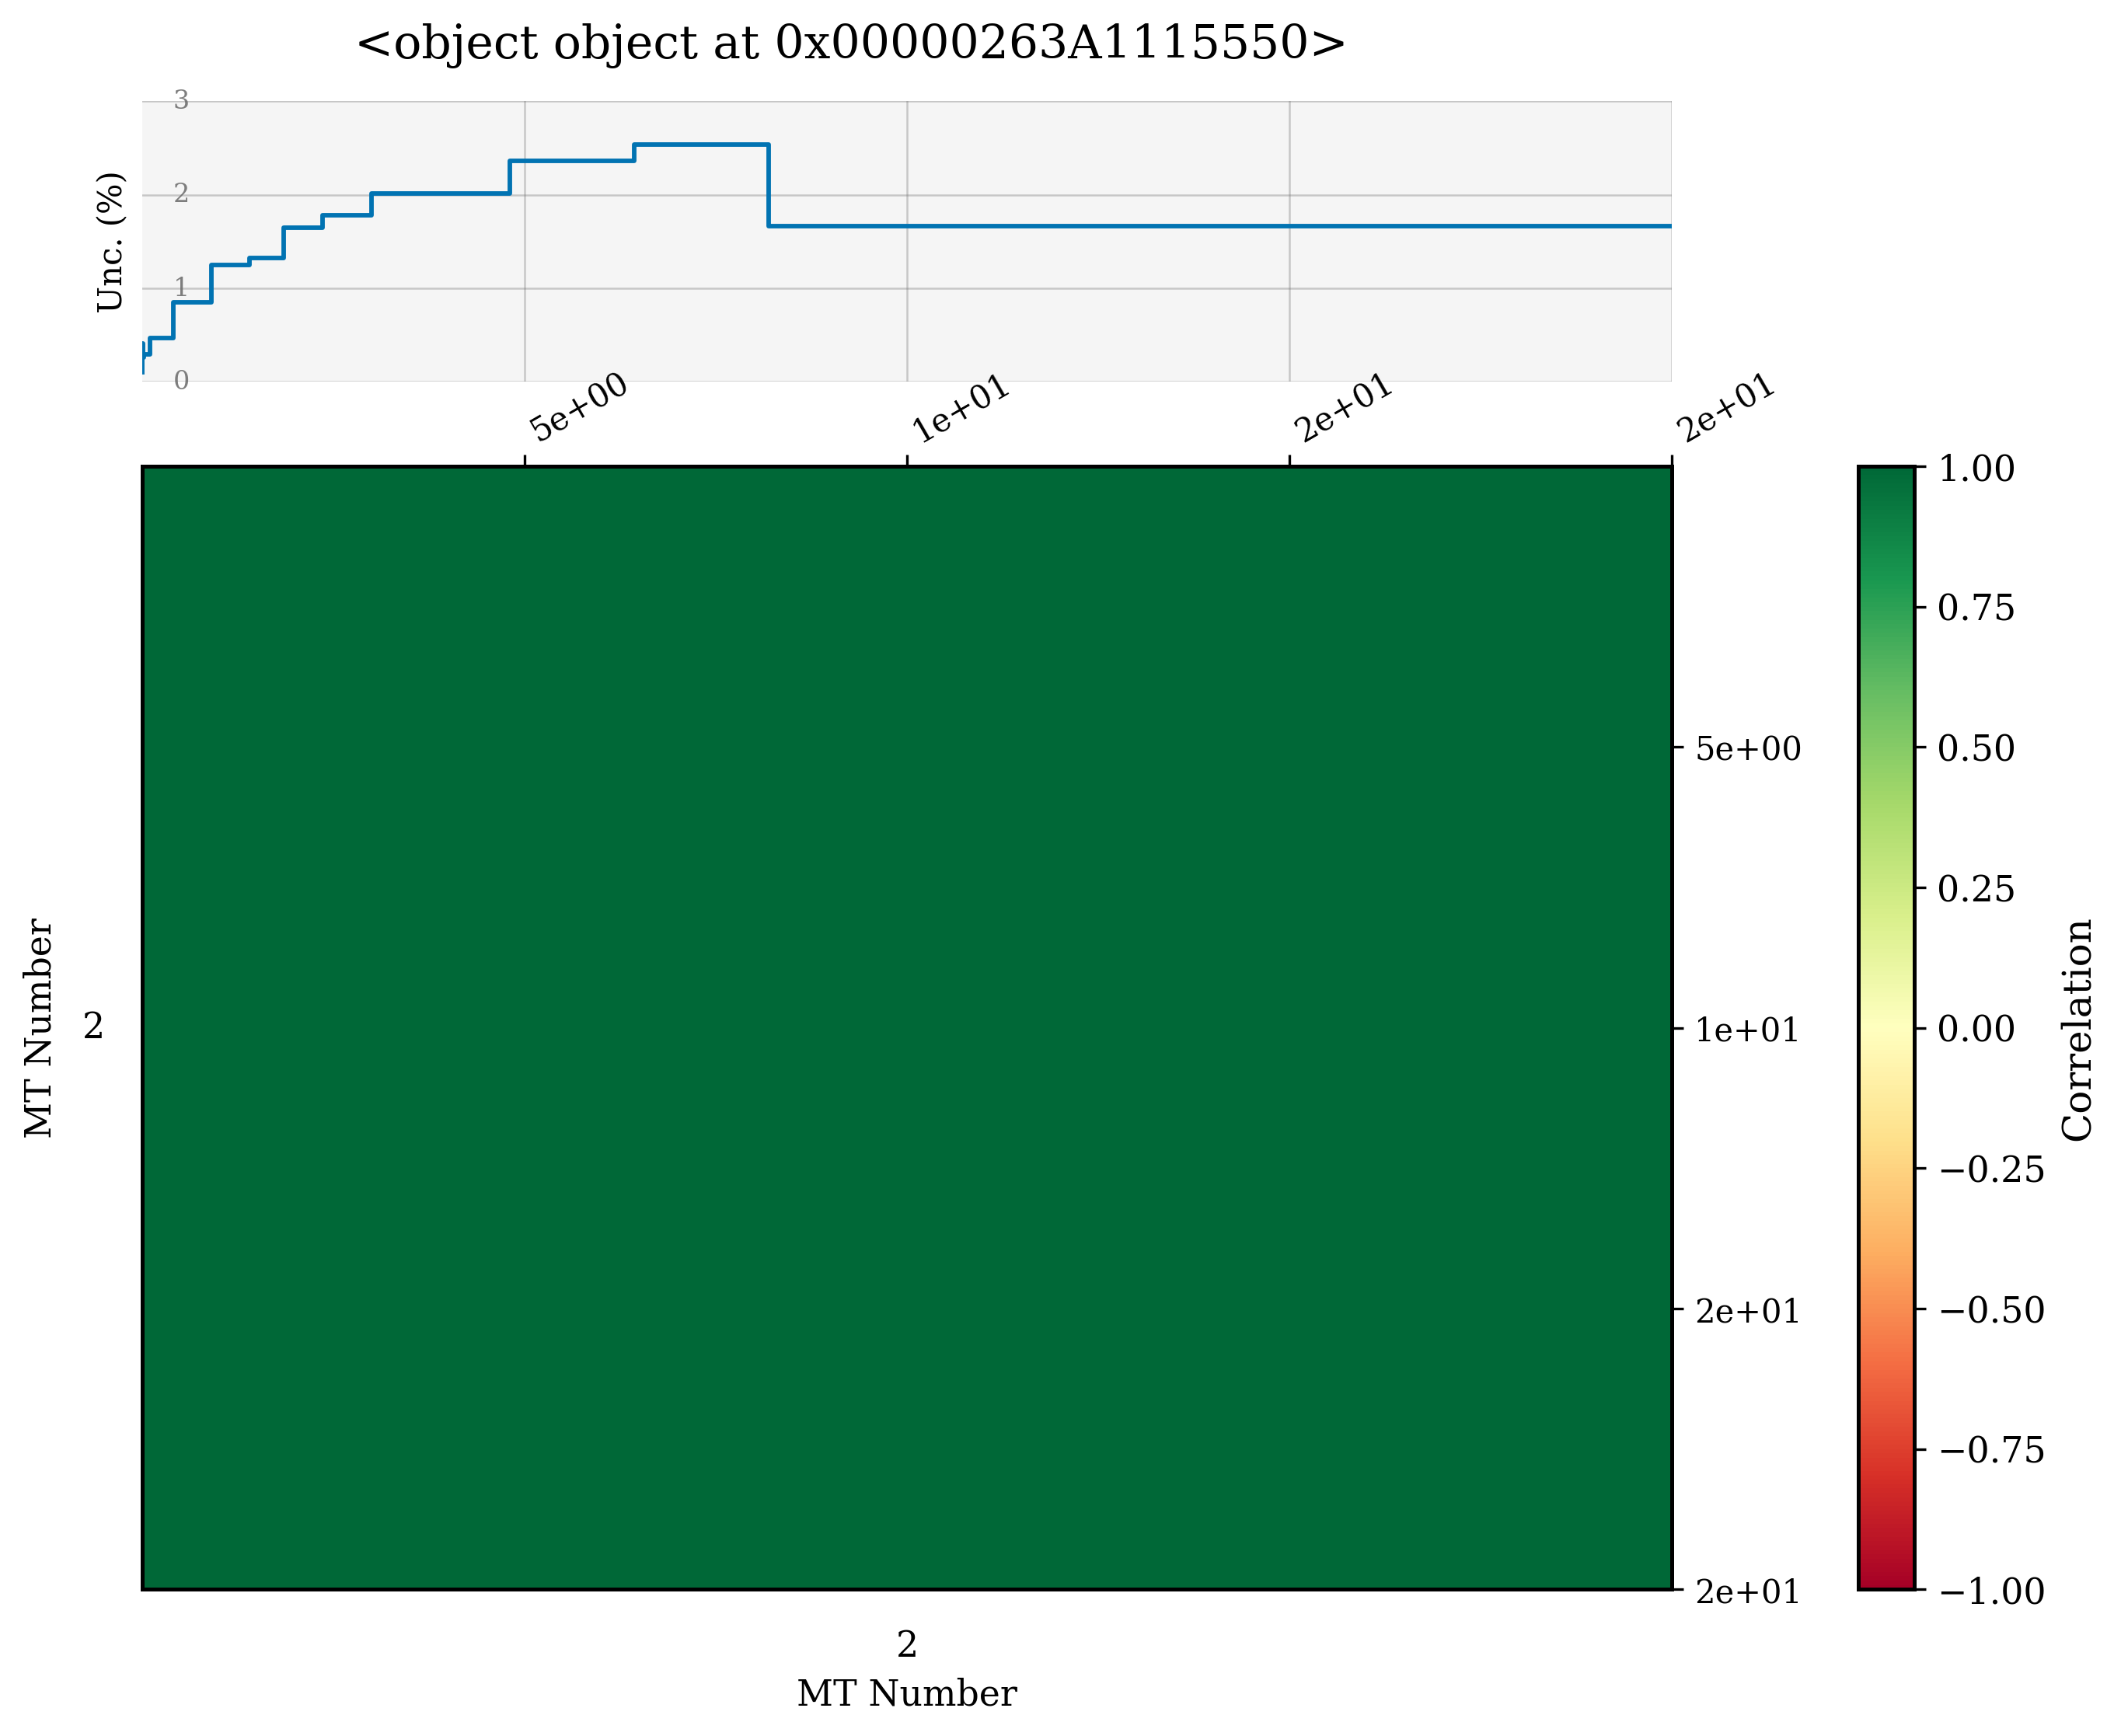

In [15]:
# Plot correlation matrix for H-1 elastic scattering
if 1001 in covmat.isotopes:
    try:
        fig = plot_covariance_heatmap(
            covmat,
            nuclide=1001,
            mt=2,  # Elastic scattering
            matrix_type="corr",
            figsize=(8, 7),
            show_uncertainties=True,
            scale="linear"
        )
        plt.show()
    except Exception as e:
        print(f"Could not plot H-1 elastic correlation: {e}")
        print("Available reactions for H-1:", covmat.get_reactions_for_isotope(1001))
else:
    print("H-1 not found in covariance file")

## 7. Prepare SDF Data for UQ Analysis

Group inelastic reactions (MT 51-91) into MT 4 for consistency with covariance data.

In [16]:
# Group inelastic reactions before UQ analysis
print("Reactions before grouping inelastic:")
print(f"  Total profiles: {len(sdf_data.data)}")

# Group inelastic (MT 51-91 → MT 4)
sdf_data.group_inelastic_reactions(replace=True)

print(f"\nReactions after grouping inelastic:")
print(f"  Total profiles: {len(sdf_data.data)}")

# Show which reactions remain
print("\nRemaining reactions after grouping:")
for sens in sdf_data.data:
    print(f"  {sens.nuclide:8s} MT={sens.mt:3d} ({sens.reaction_name})")

Reactions before grouping inelastic:
  Total profiles: 14

Reactions after grouping inelastic:
  Total profiles: 14

Remaining reactions after grouping:
  H-1      MT=  1 ((n,total).)
  H-1      MT=  2 ((z,z0))
  H-1      MT=102 ((z,Î³))
  O-16     MT=  1 ((n,total).)
  O-16     MT=  2 ((z,z0))
  Fe-54    MT=  1 ((n,total).)
  Fe-54    MT=  2 ((z,z0))
  Fe-54    MT=  4 ((z,n'))
  Fe-54    MT=102 ((z,Î³))
  Fe-54    MT=103 ((z,p))
  Fe-56    MT=  1 ((n,total).)
  Fe-56    MT=  2 ((z,z0))
  Fe-56    MT=  4 ((z,n'))
  Fe-56    MT=102 ((z,Î³))


## 8. Perform Sandwich Uncertainty Propagation

The sandwich rule calculates response uncertainty as:

$$\sigma^2 = \mathbf{S}^T \mathbf{C} \mathbf{S}$$

where:
- $\mathbf{S}$ is the sensitivity vector
- $\mathbf{C}$ is the covariance matrix
- $\sigma^2$ is the variance of the response

In [17]:
# Perform uncertainty propagation
result = sandwich_uncertainty_propagation(
    sdf_data=sdf_data,
    cov_mat=covmat,
    verbose=True
)

# Display the full result
print("\n" + "="*80)
print("UNCERTAINTY PROPAGATION RESULT")
print("="*80)
print(result)

INFO: Starting sandwich uncertainty propagation
INFO: ============================================================
INFO: ✓ Input validation complete
INFO:   Cross-section covariances: 1 files with 2211 total matrices
INFO:   Found 10 cross-section sensitivities (excluding MT=1)
INFO:   Found 0 Legendre moment sensitivities
INFO: Processing cross-section sensitivities...
INFO: Matched 44/44 energy groups
INFO: Found 10 matching cross-section
INFO:   Fe-54 (n,p)
INFO:   Fe-56 (n,n')
INFO:   H-1 (n,γ)
INFO:   Fe-54 (n,γ)
INFO:   H-1 (n,el)
INFO:   ... and 5 more
INFO: ✓ Cross-section processing complete: 10 reactions
INFO: Building combined sensitivity vector and covariance matrix...
INFO: Building matrices: 10 reactions × 44 groups = 440 total elements
INFO: Sensitivity vector: 56/440 non-zero elements
INFO: Covariance matrix: 12680/193600 non-zero elements
INFO: Max sensitivity coefficient: 6.790610e-01
INFO: Max covariance element: 2.403300e-01
INFO: Typical relative uncertainty: 0.107


UNCERTAINTY PROPAGATION RESULT
UNCERTAINTY PROPAGATION RESULTS (Sandwich Formula)

RESPONSE VALUE WITH UNCERTAINTIES:
--------------------------------------------------
Response value:                    6.184000e-04

STATISTICAL UNCERTAINTY (from Monte Carlo):
  • Absolute:                      ± 5.904543e-09
  • Relative:                      ± 0.001%

NUCLEAR DATA UNCERTAINTY (from covariances):
  • Absolute:                      ± 4.009562e-05
  • Relative:                      ± 6.484%

TOTAL UNCERTAINTY (statistical + nuclear data):
  • Absolute:                      ± 4.009562e-05
  • Relative:                      ± 6.484%

FINAL RESULT:
  Response = 6.184000e-04 ± 4.009562e-05
  Response = 6.184000e-04 ± 6.484%

PROPAGATION DETAILS:
--------------------------------------------------
Total variance (σ²):               4.203924e-03
Reactions included:                10
Energy groups:                     44
Cross-reaction correlations:       -6.607614e-04 (15.7% of total)

INDIV

## 9. Analyze Uncertainty Contributions

Break down the total uncertainty by nuclide and reaction to identify the dominant contributors.

In [18]:
# Create DataFrame of contributions sorted by importance
contributions_data = []
for contrib in result.contributions:
    contributions_data.append({
        'Nuclide': contrib.nuclide,
        'Reaction': contrib.reaction_name,
        'ZAID': contrib.zaid,
        'MT': contrib.mt,
        'Variance': contrib.variance_contribution,
        'Std Dev': contrib.uncertainty_contribution,
        'Fraction (%)': contrib.relative_contribution * 100
    })

df_contrib = pd.DataFrame(contributions_data)
df_contrib = df_contrib.sort_values('Fraction (%)', ascending=False)

print("\nTop 15 contributors to uncertainty:")
print("="*80)
print(df_contrib.head(15).to_string(index=False))

print(f"\n\nTotal accounted variance: {df_contrib['Variance'].sum():.6e}")
print(f"Cross-correlation contribution: {result.correlation_effects:.6e}")
print(f"Total variance: {result.total_variance:.6e}")


Top 15 contributors to uncertainty:
Nuclide Reaction  ZAID  MT      Variance  Std Dev  Fraction (%)
  Fe-56   (n,el) 26056   2  2.091828e-03 0.045737     49.758934
    H-1   (n,el)  1001   2  1.390361e-03 0.037288     33.072943
  Fe-56   (n,n') 26056   4  4.775655e-04 0.021853     11.359995
   O-16   (n,el)  8016   2  1.890091e-04 0.013748      4.496016
  Fe-54   (n,el) 26054   2  5.569003e-05 0.007463      1.324716
  Fe-54   (n,n') 26054   4  1.583300e-06 0.001258      0.037662
  Fe-54    (n,γ) 26054 102  2.280029e-08 0.000151      0.000542
    H-1    (n,γ)  1001 102  5.116004e-10 0.000023      0.000012
  Fe-54    (n,p) 26054 103 -1.445375e-09 0.000038     -0.000034
  Fe-56    (n,γ) 26056 102 -2.135012e-06 0.001461     -0.050786


Total accounted variance: 4.203924e-03
Cross-correlation contribution: -6.607614e-04
Total variance: 4.203924e-03


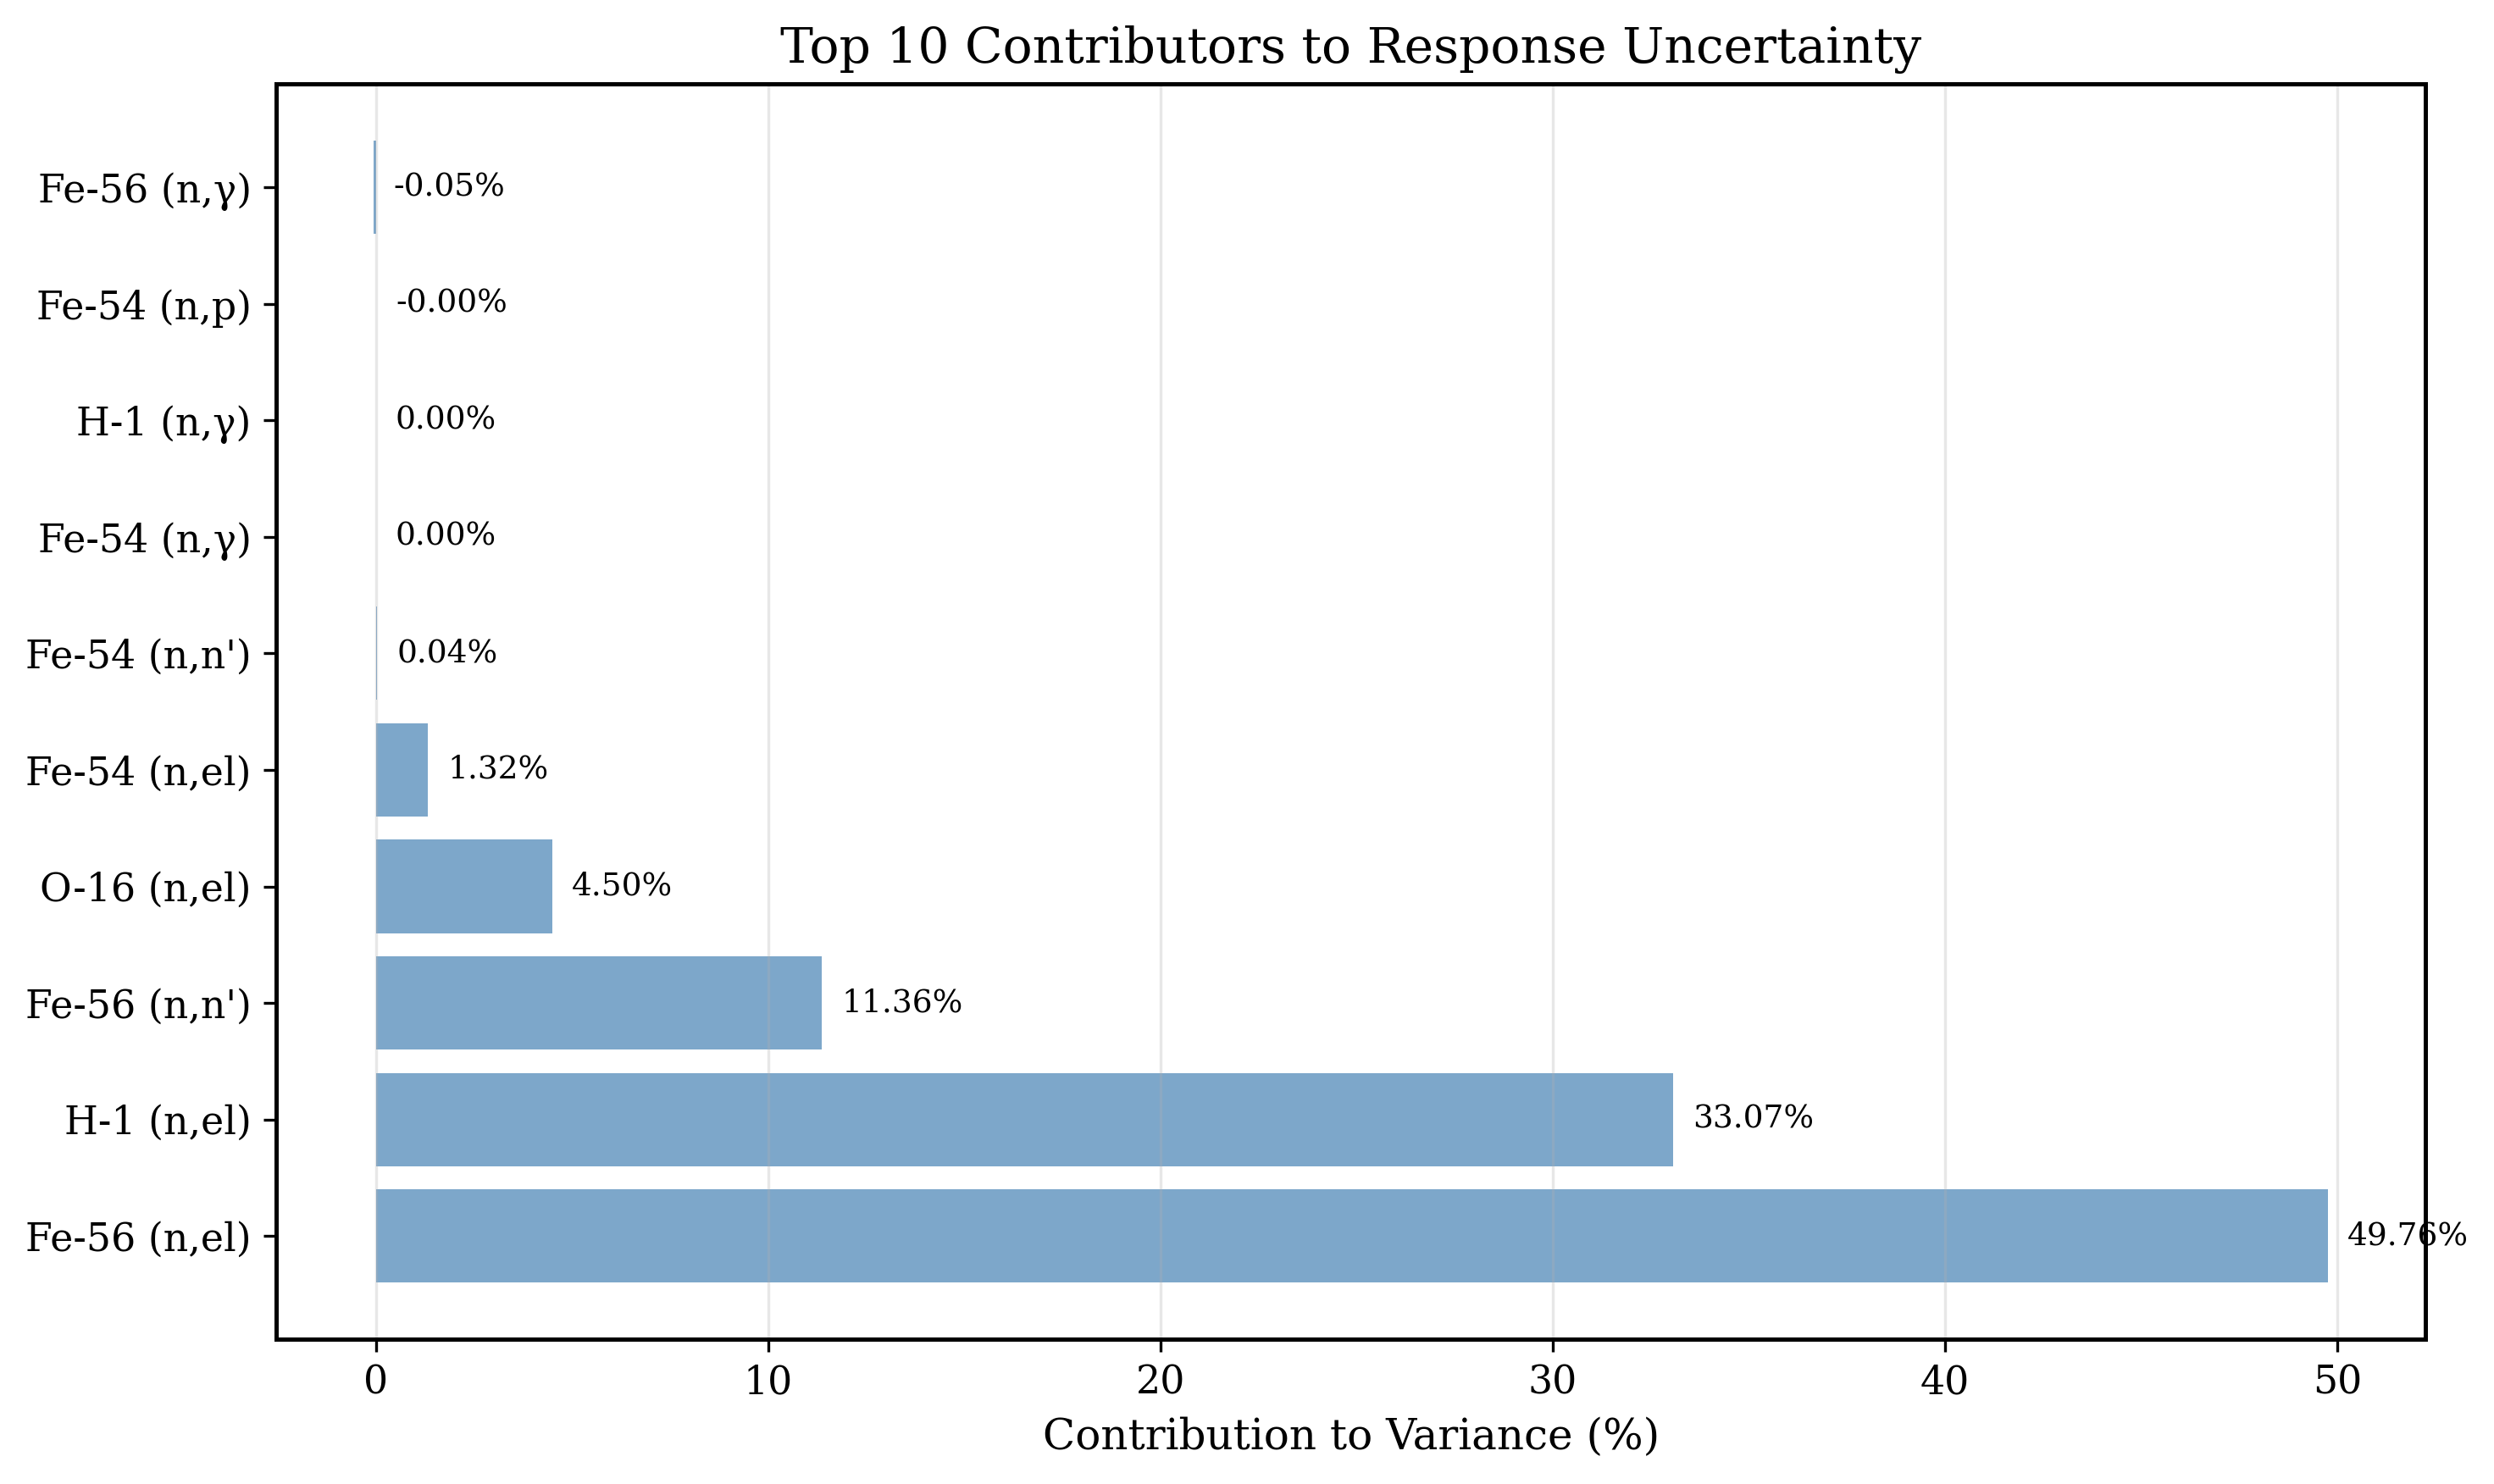

In [19]:
# Visualize top contributors
top_n = 10
df_top = df_contrib.head(top_n).copy()
df_top['Label'] = df_top['Nuclide'] + ' ' + df_top['Reaction']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(range(len(df_top)), df_top['Fraction (%)'], color='steelblue', alpha=0.7)
ax.set_yticks(range(len(df_top)))
ax.set_yticklabels(df_top['Label'])
ax.set_xlabel('Contribution to Variance (%)', fontsize=12)
ax.set_title(f'Top {top_n} Contributors to Response Uncertainty', fontsize=14)
ax.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, (idx, row) in enumerate(df_top.iterrows()):
    ax.text(row['Fraction (%)'] + 0.5, i, f"{row['Fraction (%)']:.2f}%", 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()


Contributions aggregated by nuclide:
Nuclide  Variance  Fraction (%)
  Fe-56  0.002567     61.068143
    H-1  0.001390     33.072955
   O-16  0.000189      4.496016
  Fe-54  0.000057      1.362886


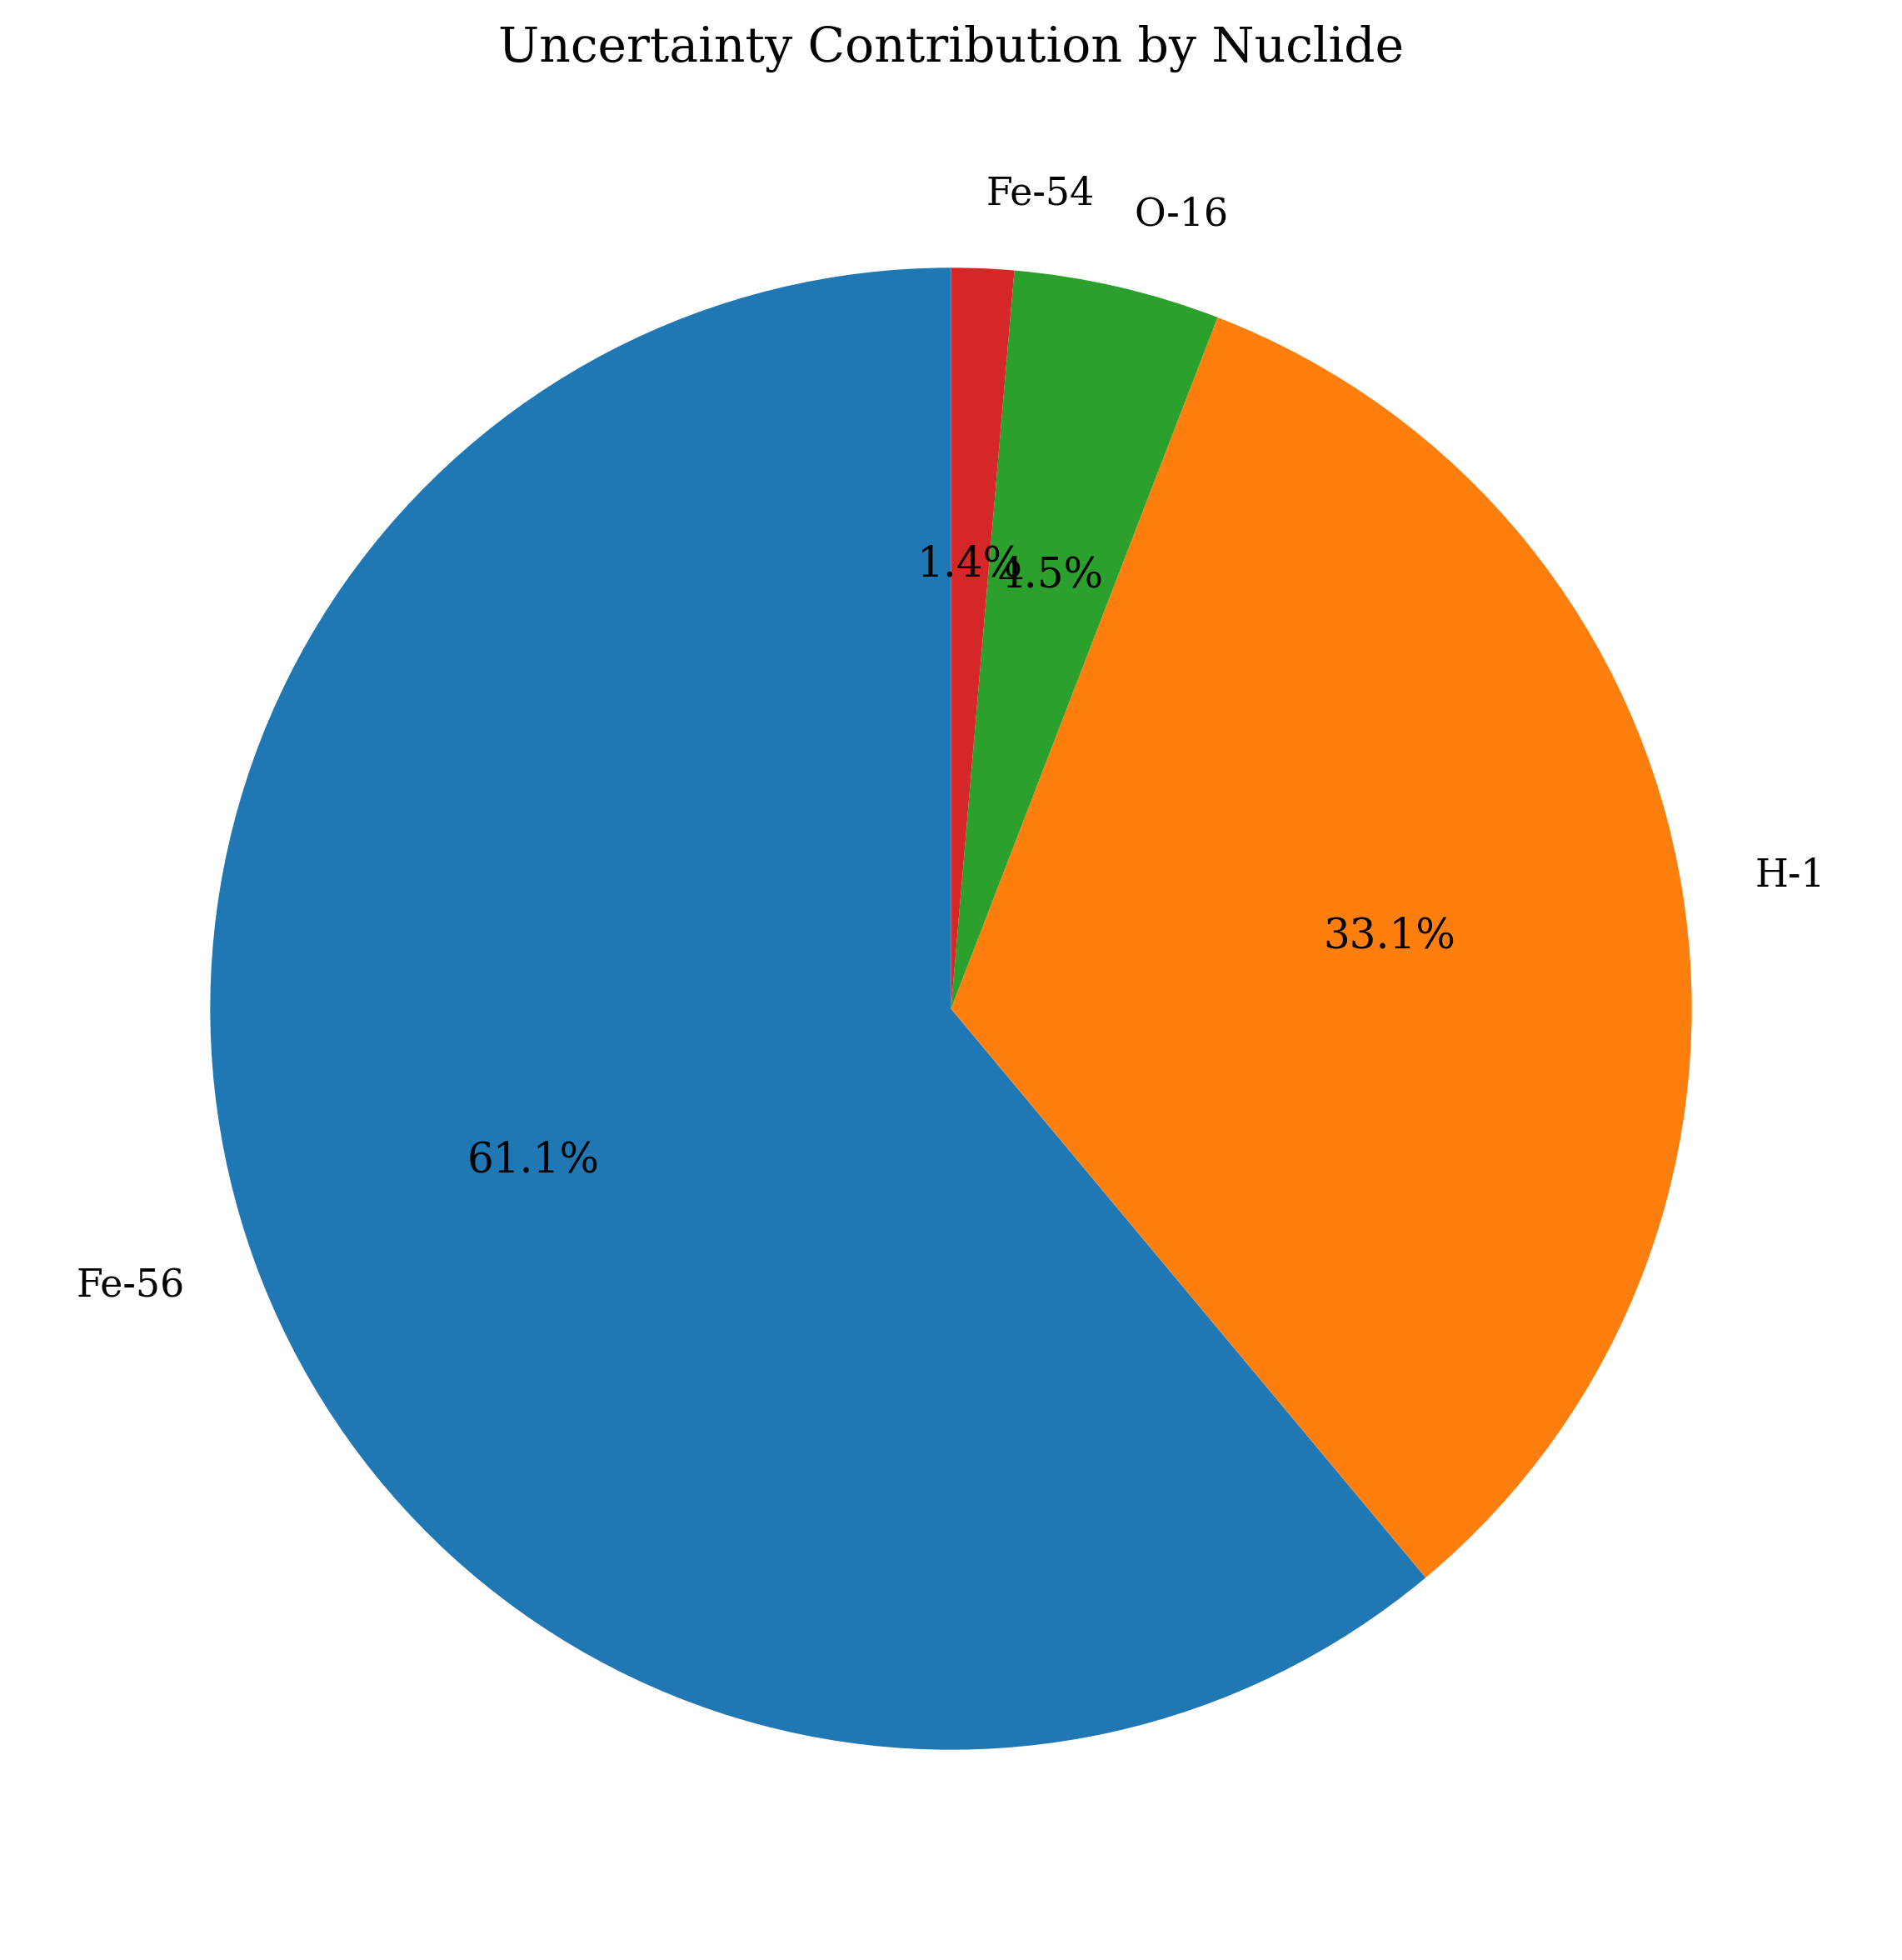

In [20]:
# Aggregate contributions by nuclide
nuclide_contrib = df_contrib.groupby('Nuclide').agg({
    'Variance': 'sum',
    'Fraction (%)': 'sum'
}).reset_index()
nuclide_contrib = nuclide_contrib.sort_values('Fraction (%)', ascending=False)

print("\nContributions aggregated by nuclide:")
print("="*60)
print(nuclide_contrib.to_string(index=False))

# Pie chart of nuclide contributions
fig, ax = plt.subplots(figsize=(10, 8))
top_nuclides = nuclide_contrib.head(8)
other_fraction = nuclide_contrib.iloc[8:]['Fraction (%)'].sum() if len(nuclide_contrib) > 8 else 0

if other_fraction > 0:
    labels = list(top_nuclides['Nuclide']) + ['Others']
    sizes = list(top_nuclides['Fraction (%)']) + [other_fraction]
else:
    labels = list(top_nuclides['Nuclide'])
    sizes = list(top_nuclides['Fraction (%)'])

ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
ax.set_title('Uncertainty Contribution by Nuclide', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Summary and Key Findings

In [21]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\nResponse Value: {result.response_value:.6e} ± {result.total_uncertainty:.6e}")
print(f"Relative Uncertainty: {result.relative_uncertainty*100:.4f}%")
print(f"\nTotal Variance: {result.total_variance:.6e}")
print(f"  - From individual reactions: {sum(c.variance_contribution for c in result.contributions):.6e}")
print(f"  - From cross-correlations: {result.correlation_effects:.6e}")
print(f"\nNumber of reactions analyzed: {result.n_reactions}")
print(f"Number of contributing reactions: {len([c for c in result.contributions if c.variance_contribution != 0])}")
print(f"\nTop 3 contributors:")
for i, (idx, row) in enumerate(df_contrib.head(3).iterrows(), 1):
    print(f"  {i}. {row['Nuclide']} {row['Reaction']}: {row['Fraction (%)']:.2f}%")

print("\n" + "="*80)
print("\nKEY CAPABILITIES DEMONSTRATED:")
print("="*80)
print("✓ Read SDF sensitivity files using kika.read_sdf()")
print("✓ Access SDFData attributes (pert_energies, data, r0, e0)")
print("✓ Iterate over SDFReactionData objects (zaid, mt, nuclide, sensitivity)")
print("✓ Load SCALE covariance matrices with kika.read_scale_covmat()")
print("✓ Explore CovMat properties (isotopes, reactions, covariance_matrix)")
print("✓ Visualize correlation matrices with plot_covariance_heatmap()")
print("✓ Group inelastic reactions using sdf_data.group_inelastic_reactions()")
print("✓ Perform sandwich uncertainty propagation")
print("✓ Analyze UncertaintyResult with detailed contribution breakdown")
print("✓ Identify dominant uncertainty contributors")
print("="*80)

FINAL SUMMARY

Response Value: 6.184000e-04 ± 6.483767e-02
Relative Uncertainty: 6.4838%

Total Variance: 4.203924e-03
  - From individual reactions: 4.203924e-03
  - From cross-correlations: -6.607614e-04

Number of reactions analyzed: 10
Number of contributing reactions: 10

Top 3 contributors:
  1. Fe-56 (n,el): 49.76%
  2. H-1 (n,el): 33.07%
  3. Fe-56 (n,n'): 11.36%


KEY CAPABILITIES DEMONSTRATED:
✓ Read SDF sensitivity files using kika.read_sdf()
✓ Access SDFData attributes (pert_energies, data, r0, e0)
✓ Iterate over SDFReactionData objects (zaid, mt, nuclide, sensitivity)
✓ Load SCALE covariance matrices with kika.read_scale_covmat()
✓ Explore CovMat properties (isotopes, reactions, covariance_matrix)
✓ Visualize correlation matrices with plot_covariance_heatmap()
✓ Group inelastic reactions using sdf_data.group_inelastic_reactions()
✓ Perform sandwich uncertainty propagation
✓ Analyze UncertaintyResult with detailed contribution breakdown
✓ Identify dominant uncertainty contr